# PV-relative tilt: planetary, mixed and topographic
One **2×3** comparison: planetary / mixed / topographic columns; **along-PV-gradient** above **perpendicular**. AE red, CE blue. Curves are signed mean constituent-centre displacements in kilometres, relative to each day's own surface centre.

Select eddy-days with **`surface.TiltDis >= 5 km`**. This is a day-selection criterion using the existing tilt measurement, not a 5 km threshold applied to each plotted depth. Retain all valid fitted levels at **0–1000 m inclusive** from selected days, including the zero-displacement surface. No region, Rossby or shallow/deep-eddy split.

- **Planetary:** planetary gradient magnitude ≥2× topographic magnitude **and `surface.h > 3000 m`**.
- **Topographic:** topographic magnitude ≥2× planetary magnitude **and `surface.h < 3000 m`**.
- **Mixed:** neither complete selection above. This includes ratio-dominated days in the opposite water-depth range and days at exactly 3000 m. Missing/invalid classification inputs are excluded, not assigned mixed.

The fixed reference is **`PV_grad_mag` / `PV_grad_theta`**, the total environmental planetary+topographic gradient, in every column. Rotate each day's centres before averaging. Positive along means with the gradient; positive perpendicular is 90° anticlockwise. `h` is water depth from the surface PV calculation (footprint-mean for the settings below), separate from profile depth.

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
HERE = Path.cwd().resolve()
ANALYSIS = next((p for p in (HERE, *HERE.parents) if (p/'seacofs_tilt_tools.py').exists()), None)
if ANALYSIS is None:
    candidate = HERE/'seacofs_eddy_tilt_analysis'
    ANALYSIS = candidate if (candidate/'seacofs_tilt_tools.py').exists() else None
if ANALYSIS is None: raise FileNotFoundError('Run from UNSW-PhD or the analysis folder or a subfolder')
WORK = ANALYSIS/'esp_population_composites'
for p in (ANALYSIS, WORK):
    if str(p) not in sys.path: sys.path.insert(0, str(p))
import seacofs_tilt_tools as tilt
import pv_dominance_tilt_tools as pdt

In [2]:
MIN_TILT_KM = 5.             # selection uses surface.TiltDis
DOMINANCE_FACTOR = 2.
WATER_DEPTH_M = 3000.
MAX_PROFILE_DEPTH_M = 1000. # applied to DATA before averaging/bootstrap
ELLIPSE_FRAC = 1.
USE_PV_CACHE = True         # False recalculates and overwrites the ONE surface cache
BOOTSTRAPS = 500
SEED = 731
MIN_PLOT_EDDIES = 2
SPARSE_EDDIES = 20

In [3]:
paths = tilt.Paths()
grid = tilt.load_grid(paths.grid, paths.z_r)
surface, _ = tilt.load_tilt_tables(paths, add_regions=False, grid=grid)
vertical = tilt.load_vert(paths)
surface = tilt.add_pv_gradient_terms(
    surface, grid, core_mean=True, frac=ELLIPSE_FRAC,
    surface_method='esp_gaussian', averaging='nonlinear',
    use_max_abs_w=True, max_depth_m=1000., vertical=vertical,
    use_cache=USE_PV_CACHE,
)
# If the cache's settings/data have changed, run once with USE_PV_CACHE=False.
day_audit, members = pdt.prepare(
    surface, vertical, grid.angle, min_tilt_km=MIN_TILT_KM,
    dominance_factor=DOMINANCE_FACTOR, water_depth_m=WATER_DEPTH_M,
    max_profile_depth_m=MAX_PROFILE_DEPTH_M,
)
display(day_audit.groupby('selection_status').agg(eddy_days=('Day','size'), eddies=('Eddy','nunique')))

,eddy_days,eddies
selection_status,,
missing/invalid surface TiltDis,25770,2982
selected,91880,2943
surface TiltDis below threshold,9776,1619


## Composite constituent centrelines
Each available eddy-day has equal weight at each exact fitted depth. Validity follows the existing ESP-profile checks and requires a valid surface fit. No new ESP velocity reconstruction is needed.

Pointwise 95% confidence bands resample **whole eddy tracks**, preserving their days and depths. They describe uncertainty in the mean, not individual-centre spread or ESP fit uncertainty. Tracks may enter different categories on different days; counts across categories must not be summed as distinct tracks. Available contributors can change with depth. No interpolation/extrapolation is used to manufacture a 1000 m sample.

,regime,Cyc,eddy_days,eddies,deepest_contributing_m
0,planetary,AE,4437,494,858.918478
1,planetary,CE,1706,375,858.918478
2,mixed,AE,37039,1266,858.918478
3,mixed,CE,35149,1368,858.918478
4,topographic,AE,5291,335,858.918478
5,topographic,CE,8258,586,858.918478


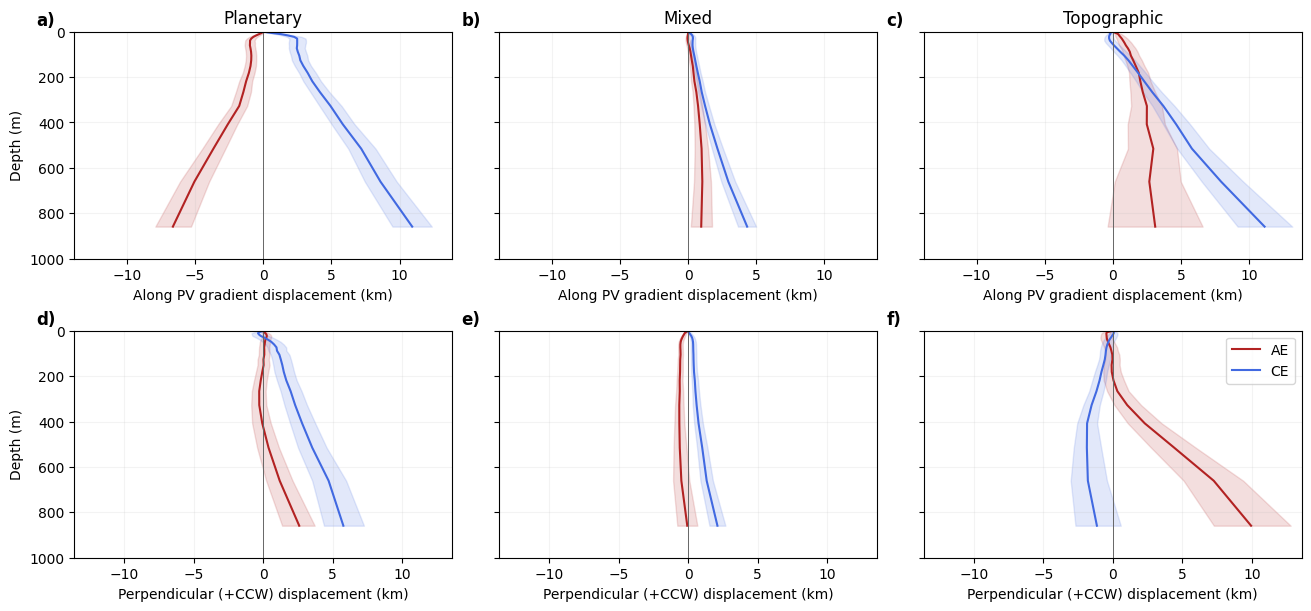

In [4]:
centre_stats, inventory = pdt.summarise(members, n_boot=BOOTSTRAPS, seed=SEED)
display(inventory)
fig, axes = pdt.plot(centre_stats, max_depth_m=MAX_PROFILE_DEPTH_M,
                     min_eddies=MIN_PLOT_EDDIES, sparse_eddies=SPARSE_EDDIES)
plt.show()

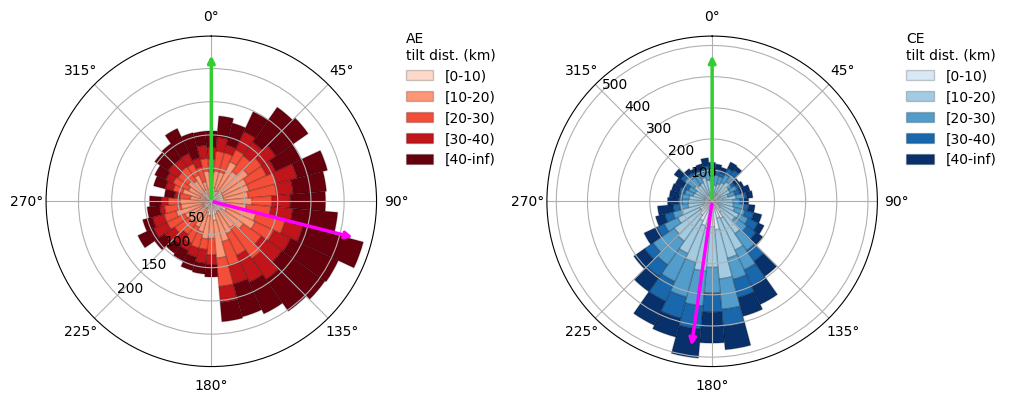

In [5]:
# Til direction relative to slope
topographic = surface[(surface.topo_plan_ratio_smooth>=np.log(2))&(surface.TiltDis>=MIN_TILT_KM)&(surface.h<=WATER_DEPTH_M)].copy()
fig, axs = plt.subplots(1, 2, figsize=(10, 5), subplot_kw={'projection':'polar'}, constrained_layout=True)
mag_bins = [0, 10, 20, 30, 40, np.inf]
for ax, cyc, colors in zip(axs, ['AE','CE'], [plt.cm.Reds(np.linspace(.15,1,len(mag_bins)-1)), plt.cm.Blues(np.linspace(.15,1,len(mag_bins)-1))]):
    df = topographic[(topographic.Cyc==cyc)].dropna(subset=['TiltDir','TiltDis']).copy()
    df['theta'] = df.TiltDir - df.PV_grad_theta
    tilt.plot_windrose(ax, df, title='', mag_bins=mag_bins, colors=colors, theta='theta')
    th = np.deg2rad(df.theta)
    th = np.arctan2(np.mean(np.sin(th)), np.mean(np.cos(th)))
    ax.annotate('', xy=(th,.9*ax.get_ylim()[1]), xytext=(th,0),
                arrowprops=dict(arrowstyle='->', lw=2.5, color='magenta'))
    ax.annotate('', xy=(0.0,.9*ax.get_ylim()[1]), xytext=(th,0),
                arrowprops=dict(arrowstyle='->', lw=2.5, color='limegreen'))
    ax.legend(title=f'{cyc}\ntilt dist. (km)', loc='upper left', bbox_to_anchor=(1.05,1.05), frameon=False)

plt.show()

In [8]:
surface.columns

Index(['Eddy', 'Day', 'Cyc', 'lon', 'lat', 'ic', 'jc', 'xc', 'yc', 'w',
       'Omega', 'q11', 'q12', 'q22', 'Rc', 'psi0', 'AR', 'R', 'Age', 'Date',
       'fname', 'TiltDis', 'TiltDir', 'Region', 'w_surface',
       'w_selected_depth_m', 'w_profile_n', 'h', 'f', 'beta', 'dhdx', 'dhdy',
       'zeta_mean', 'abs_vort', 'PV', 'PV_footprint_n',
       'PV_weight_effective_n', 'PV_grad_plan_x', 'PV_grad_plan_y',
       'PV_grad_plan_mean_local_mag', 'PV_grad_plan_rms_local_mag',
       'PV_grad_plan_p90_local_mag', 'PV_grad_plan_coherence',
       'PV_grad_topo_x', 'PV_grad_topo_y', 'PV_grad_topo_mean_local_mag',
       'PV_grad_topo_rms_local_mag', 'PV_grad_topo_p90_local_mag',
       'PV_grad_topo_coherence', 'PV_grad_x', 'PV_grad_y',
       'PV_grad_mean_local_mag', 'PV_grad_rms_local_mag',
       'PV_grad_p90_local_mag', 'PV_grad_coherence', 'PV_grad_eddy_x',
       'PV_grad_eddy_y', 'PV_grad_eddy_mean_local_mag',
       'PV_grad_eddy_rms_local_mag', 'PV_grad_eddy_p90_local_mag',
     

<Axes: xlabel='topo_plan_ratio'>

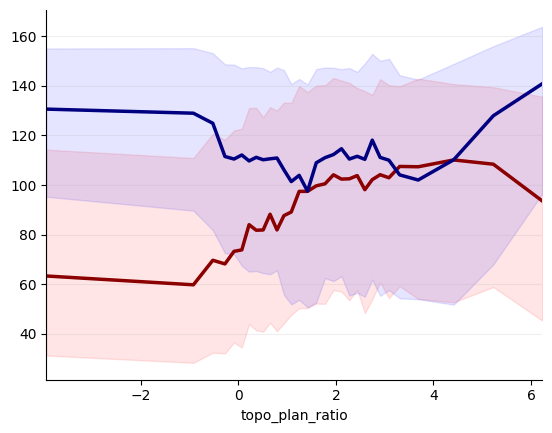

In [10]:
fig, ax = plt.subplots()
tilt.binned_tilt_panel(ax, surface, 'topo_plan_ratio', 'topo_plan_ratio', ycol='dtheta_PV_grad')

`members` contains the projected constituent centres; `day_audit` records selection and exclusions. `centre_stats` contains the means, variances, confidence intervals and contributing eddy/day counts at each depth. Use the support table below when interpreting the deeper part of a curve. No dataset conclusions are assumed before running.

In [6]:
support_columns = ['regime','Cyc','Depth','n_eddy_days','n_eddies']
support = centre_stats.reindex(columns=support_columns)
display(support)

,regime,Cyc,Depth,n_eddy_days,n_eddies
0,planetary,AE,0.000000,4437,494
1,planetary,AE,5.879627,4437,494
2,planetary,AE,10.725783,4437,494
3,planetary,AE,16.383097,4437,494
4,planetary,AE,22.925581,4437,494
...,...,...,...,...,...
127,topographic,CE,327.440851,7979,576
128,topographic,CE,407.922192,7701,566
129,topographic,CE,515.416489,7339,560
130,topographic,CE,660.806374,6812,546
